## 🎯 Misión

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.

## 🧠 Objetivos del Desafío

Preparar los datos para el modelado (tratamiento, codificación, normalización).

Realizar análisis de correlación y selección de variables.

Entrenar dos o más modelos de clasificación.

Evaluar el rendimiento de los modelos con métricas.

Interpretar los resultados, incluyendo la importancia de las variables.

Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.

In [77]:
import pandas as pd

In [78]:
df = pd.read_csv('datos_tratados.csv')
df.head()

,Churn,Customer_Gender,Customer_SeniorCitizen,Customer_Partner,Customer_Dependents,Customer_Tenure,Phone_PhoneService,Phone_MultipleLines,Internet_InternetService,Internet_OnlineSecurity,...,Account_Contract,Account_PaperlessBilling,Account_PaymentMethod,Charges_Monthly,Charges_Total,Account_Daily,Charges_Monthly_bin,Charges_Total_bin,Account_Daily_bin,Customer_Tenure_bin
0,0,Female,0,1,1,9,1,No,DSL,No,...,One year,1,Mailed check,65.6,593.30,2.2,"(58.83, 79.1]","(265.32, 939.78]","(2.0, 2.6]","(6.0, 20.0]"
1,0,Male,0,0,0,9,1,Yes,DSL,No,...,Month to month,0,Mailed check,59.9,542.40,2.0,"(58.83, 79.1]","(265.32, 939.78]","(0.8, 2.0]","(6.0, 20.0]"
2,1,Male,0,0,0,4,1,No,Fiber optic,No,...,Month to month,1,Electronic check,73.9,280.85,2.5,"(58.83, 79.1]","(265.32, 939.78]","(2.0, 2.6]","(-0.001, 6.0]"
3,1,Male,1,1,0,13,1,No,Fiber optic,No,...,Month to month,1,Electronic check,98.0,1237.85,3.3,"(94.25, 118.75]","(939.78, 2043.71]","(3.1, 4.0]","(6.0, 20.0]"
4,1,Female,1,1,0,3,1,No,Fiber optic,No,...,Month to month,1,Mailed check,83.9,267.40,2.8,"(79.1, 94.25]","(265.32, 939.78]","(2.6, 3.1]","(-0.001, 6.0]"


In [79]:
# Eliminar columnas irrelevantes en este caso ya no contamos con el ID_CLIENTE pero eliminamos las columnas  bin Customer_Tenure_bin y Charges_Monthly_bin, Charges_Total_bin y Account_Daily_bin
df = df.drop(columns=['Customer_Tenure_bin', 'Charges_Monthly_bin', 'Charges_Total_bin', 'Account_Daily_bin'])

In [80]:
df.head()

,Churn,Customer_Gender,Customer_SeniorCitizen,Customer_Partner,Customer_Dependents,Customer_Tenure,Phone_PhoneService,Phone_MultipleLines,Internet_InternetService,Internet_OnlineSecurity,...,Internet_DeviceProtection,Internet_TechSupport,Internet_StreamingTV,Internet_StreamingMovies,Account_Contract,Account_PaperlessBilling,Account_PaymentMethod,Charges_Monthly,Charges_Total,Account_Daily
0,0,Female,0,1,1,9,1,No,DSL,No,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.2
1,0,Male,0,0,0,9,1,Yes,DSL,No,...,No,No,No,Yes,Month to month,0,Mailed check,59.9,542.40,2.0
2,1,Male,0,0,0,4,1,No,Fiber optic,No,...,Yes,No,No,No,Month to month,1,Electronic check,73.9,280.85,2.5
3,1,Male,1,1,0,13,1,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month to month,1,Electronic check,98.0,1237.85,3.3
4,1,Female,1,1,0,3,1,No,Fiber optic,No,...,No,Yes,Yes,No,Month to month,1,Mailed check,83.9,267.40,2.8


In [81]:
# REalizar un resumen rápido de los datos
from utils import resumen_tipos
resumen_tipos(df)

,Column,Tipo,Nulos,Vacíos,Únicos,Top 5 Values
0,Churn,int64,0,0,2,"0, 1"
1,Customer_Gender,object,0,0,2,"Male, Female"
2,Customer_SeniorCitizen,int64,0,0,2,"0, 1"
3,Customer_Partner,int64,0,0,2,"0, 1"
4,Customer_Dependents,int64,0,0,2,"0, 1"
5,Customer_Tenure,int64,0,0,73,"1, 72, 2, 3, 4"
6,Phone_PhoneService,int64,0,0,2,"1, 0"
7,Phone_MultipleLines,object,0,0,3,"No, Yes, No phone service"
8,Internet_InternetService,object,0,0,3,"Fiber optic, DSL, No"
9,Internet_OnlineSecurity,object,0,0,3,"No, Yes, No internet service"


# ENCODING

Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

In [82]:
# ENCODING
# Convertir las columnas 
columns = ['Phone_MultipleLines', 'Internet_OnlineSecurity', 'Internet_OnlineBackup', 'Internet_DeviceProtection', 'Internet_TechSupport', 'Internet_StreamingTV', 'Internet_StreamingMovies']
# cambiamos los valores de No phone service y No internet service a No y después los convertimos a 0 y 1
for col in columns:
    df[col] = df[col].replace({'No phone service': 'No', 'No internet service': 'No'})
    df[col] = df[col].map({'Yes': 1, 'No': 0})


In [83]:
# Ver el resumen nuevamente para validar los cambios
resumen_tipos(df)

,Column,Tipo,Nulos,Vacíos,Únicos,Top 5 Values
0,Churn,int64,0,0,2,"0, 1"
1,Customer_Gender,object,0,0,2,"Male, Female"
2,Customer_SeniorCitizen,int64,0,0,2,"0, 1"
3,Customer_Partner,int64,0,0,2,"0, 1"
4,Customer_Dependents,int64,0,0,2,"0, 1"
5,Customer_Tenure,int64,0,0,73,"1, 72, 2, 3, 4"
6,Phone_PhoneService,int64,0,0,2,"1, 0"
7,Phone_MultipleLines,int64,0,0,2,"0, 1"
8,Internet_InternetService,object,0,0,3,"Fiber optic, DSL, No"
9,Internet_OnlineSecurity,int64,0,0,2,"0, 1"


In [84]:
# revisando cambiamos los valores de Customer_Gender de Female y Male a 0 y 1
df['Customer_Gender'] = df['Customer_Gender'].map({'Female': 0, 'Male': 1})


In [85]:
resumen_tipos(df)

,Column,Tipo,Nulos,Vacíos,Únicos,Top 5 Values
0,Churn,int64,0,0,2,"0, 1"
1,Customer_Gender,int64,0,0,2,"1, 0"
2,Customer_SeniorCitizen,int64,0,0,2,"0, 1"
3,Customer_Partner,int64,0,0,2,"0, 1"
4,Customer_Dependents,int64,0,0,2,"0, 1"
5,Customer_Tenure,int64,0,0,73,"1, 72, 2, 3, 4"
6,Phone_PhoneService,int64,0,0,2,"1, 0"
7,Phone_MultipleLines,int64,0,0,2,"0, 1"
8,Internet_InternetService,object,0,0,3,"Fiber optic, DSL, No"
9,Internet_OnlineSecurity,int64,0,0,2,"0, 1"


In [ ]:
# Ya con la mayoria de los datos en 1 y 0 realizamos la transformacion de las columnas restantes con One-Hot Encoding
from sklearn.preprocessing import OneHotEncoder
categorical_cols = ['Internet_InternetService', 'Account_Contract', 'Account_PaymentMethod']

# df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

encoder = OneHotEncoder(drop='first', sparse_output=False)

# Ajustamos y transformamos las columnas categóricas
encoded = encoder.fit_transform(df[categorical_cols])

# Convertimos a DataFrame
df_encoded = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))

# Concatenamos con las columnas numéricas
df_final = pd.concat([df.drop(columns=categorical_cols), df_encoded], axis=1)




In [87]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Churn                                        7043 non-null   int64  
 1   Customer_Gender                              7043 non-null   int64  
 2   Customer_SeniorCitizen                       7043 non-null   int64  
 3   Customer_Partner                             7043 non-null   int64  
 4   Customer_Dependents                          7043 non-null   int64  
 5   Customer_Tenure                              7043 non-null   int64  
 6   Phone_PhoneService                           7043 non-null   int64  
 7   Phone_MultipleLines                          7043 non-null   int64  
 8   Internet_OnlineSecurity                      7043 non-null   int64  
 9   Internet_OnlineBackup                        7043 non-null   int64  
 10  

# Verificación de la Proporción de Cancelación (Churn)

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados

In [88]:
# Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados
# Distribución absoluta
counts = df['Churn'].value_counts()

# Proporciones relativas
proportions = df['Churn'].value_counts(normalize=True).round(2) * 100

print("Distribución de clases (absoluta):")
print(counts)
print("\nDistribución de clases (proporcional):")
print(proportions)


Distribución de clases (absoluta):
Churn
0    5174
1    1869
Name: count, dtype: int64

Distribución de clases (proporcional):
Churn
0    73.0
1    27.0
Name: proportion, dtype: float64


# BALANCEO DE CLASES

In [89]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Variable objetivo
y = df_final["Churn"]
X = df_final.drop(columns=["Churn"])

# Dividir en train y test (estratificado para mantener proporciones)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Antes de SMOTE:", y_train.value_counts())

# Aplicar SMOTE (solo al conjunto de entrenamiento)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nDespués de SMOTE:", y_train_res.value_counts())


Antes de SMOTE: Churn
0    4139
1    1495
Name: count, dtype: int64

Después de SMOTE: Churn
0    4139
1    4139
Name: count, dtype: int64


# ANÁLISIS DE CORRELACIÓN


In [124]:
corr_matrix = df_final.corr()
corr_target = corr_matrix['Churn'].sort_values(ascending=False)
corr_target

Churn                                          1.000000
Internet_InternetService_Fiber optic           0.308020
Account_PaymentMethod_Electronic check         0.301919
Charges_Monthly                                0.193356
Account_Daily                                  0.192303
Account_PaperlessBilling                       0.191825
Customer_SeniorCitizen                         0.150889
Internet_StreamingTV                           0.063228
Internet_StreamingMovies                       0.061382
Phone_MultipleLines                            0.040102
Phone_PhoneService                             0.011942
Customer_Gender                               -0.008612
Internet_DeviceProtection                     -0.066160
Internet_OnlineBackup                         -0.082255
Account_PaymentMethod_Mailed check            -0.091683
Account_PaymentMethod_Credit card automatic   -0.134302
Customer_Partner                              -0.150448
Customer_Dependents                           -0

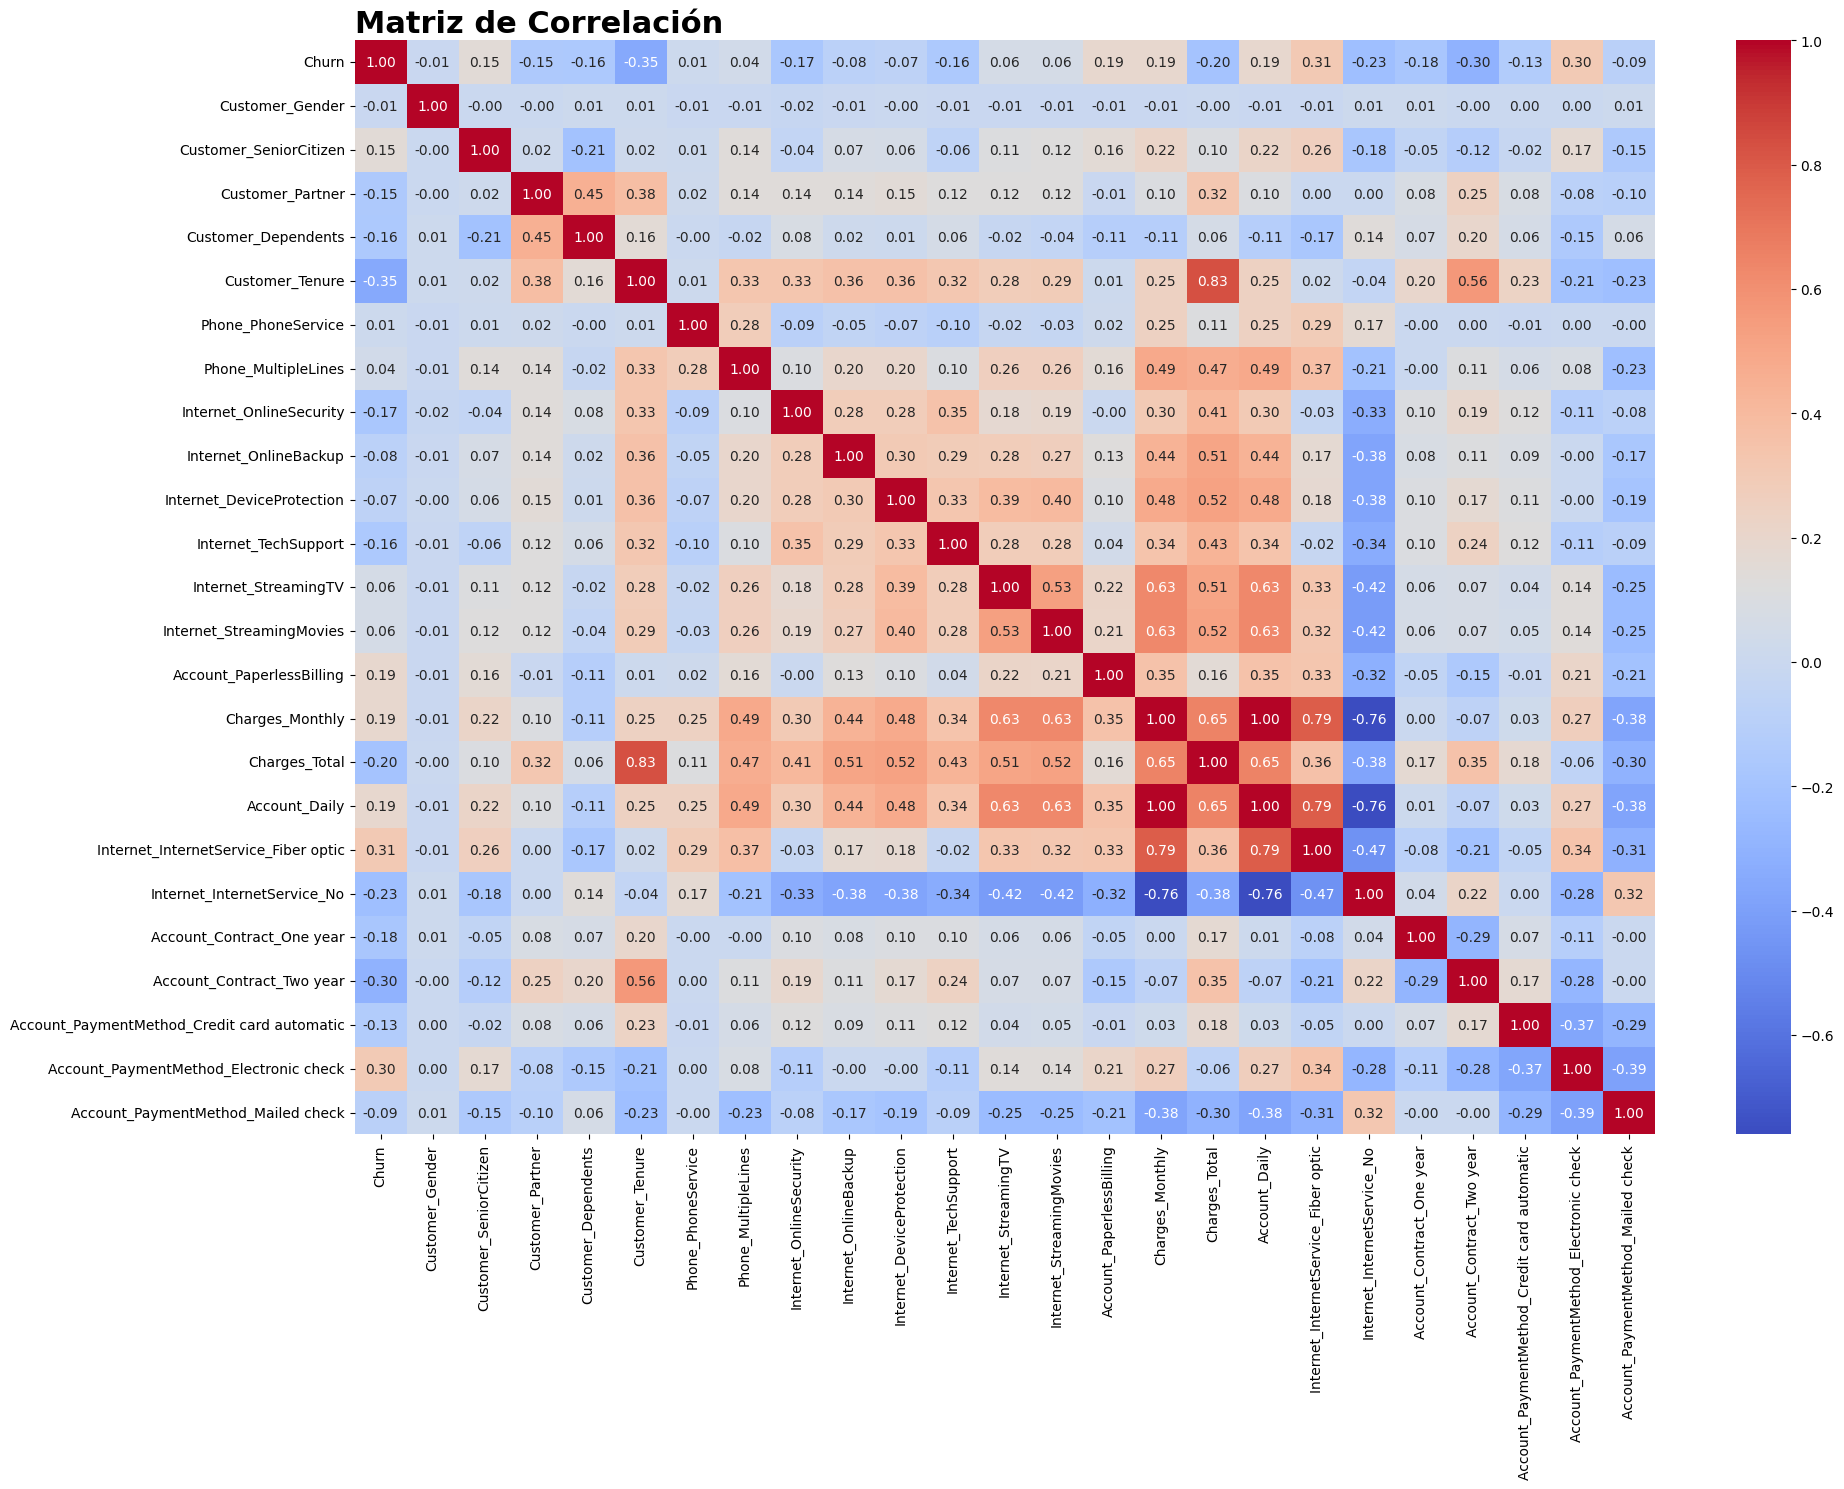

In [92]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# from utils import exportar_grafico

def heatmap_correlacion():
  # Visualizar toda la matriz
  plt.figure(figsize=(20,15))
  sns.heatmap(np.round(corr_matrix, 2), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
  plt.title("Matriz de Correlación", fontsize=22, fontweight='bold', loc='left')
  plt.tight_layout()
  return plt

heatmap_correlacion().show()
# exportar_grafico(heatmap_correlacion, "heatmap_correlacion")

En base a los datos podemos observar la correlación siguiente Los clientes nuevos, con contratos cortos, servicios de fibra óptica y pagos electrónicos son los que más riesgo tienen de cancelar, mientras que los clientes de larga permanencia, con contratos largos y servicios de soporte o seguridad son los más leales.


# ANÁLISIS DIRIGIDO - Realizando relación de variables especificas

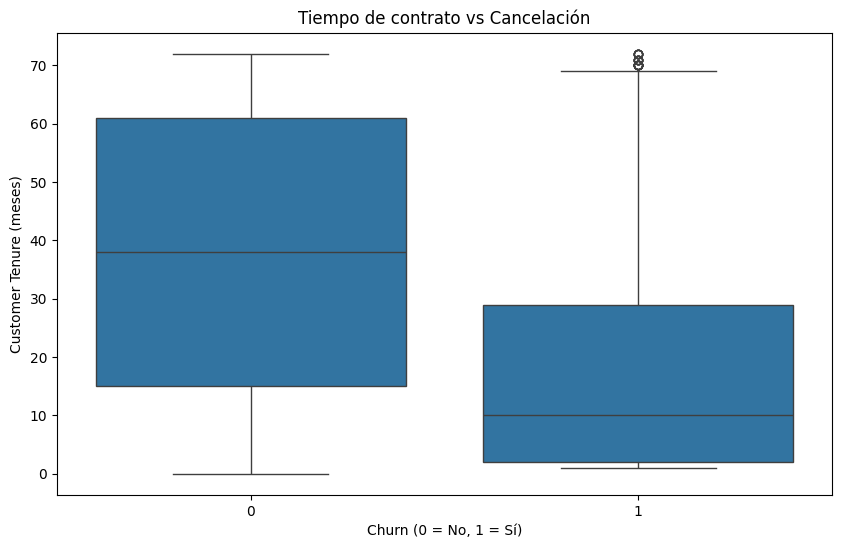

In [97]:
def Boxplot_Tenure_Churn():
  plt.figure(figsize=(10,6))
  sns.boxplot(x='Churn', y='Customer_Tenure', data=df_final)
  plt.title('Tiempo de contrato vs Cancelación')
  plt.xlabel('Churn (0 = No, 1 = Sí)')
  plt.ylabel('Customer Tenure (meses)')
  return plt
Boxplot_Tenure_Churn().show()

como se puede observar los los clientes con mas tiempo en la empresa tiene menor probabilidad de dejar el servicio. por otro lado los cliente que  tiene contratos mas cortos son mas propensos a dejar la empresa

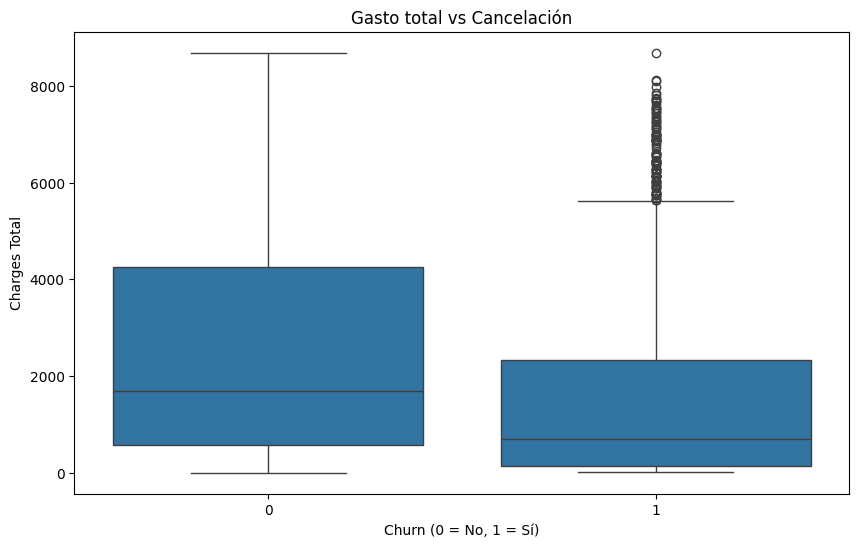

In [101]:
def Boxplot_Charges_Total_Churn():
  
  plt.figure(figsize=(10,6))
  sns.boxplot(x='Churn', y='Charges_Total', data=df_final)
  plt.title('Gasto total vs Cancelación')
  plt.xlabel('Churn (0 = No, 1 = Sí)')
  plt.ylabel('Charges Total')
  return plt

Boxplot_Charges_Total_Churn().show()

Analizando la siguiente gráfica podemos observar que los clientes que suelen dejar la empresa gastan menos también se pueden observar varios valores atípicos en un pico muy alto por arriba del 75%. 

Los clientes con gastos un poco mas centrados(mas gasto que los que abandonan pero no tan exagerados)son mas fieles.

# Separación de Datos

In [106]:
from sklearn.model_selection import train_test_split

# Separar variable objetivo y features
X = df_final.drop(columns=['Churn'])  # todas las columnas menos Churn
y = df_final['Churn']                 # variable objetivo

# Dividir en entrenamiento y prueba (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,       # 30% para prueba
    random_state=42,     # semilla para reproducibilidad
    stratify=y           # mantiene la proporción de clases en ambos conjuntos
)

# Verificar tamaño de los conjuntos
print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Dimensiones del conjunto de entrenamiento (objetivo):", y_train.shape)
print("Dimensiones del conjunto de prueba (objetivo):", y_test.shape)


Tamaño de X_train: (4930, 24)
Tamaño de X_test: (2113, 24)
Dimensiones del conjunto de entrenamiento (objetivo): (4930,)
Dimensiones del conjunto de prueba (objetivo): (2113,)


# Creacion de modelos 



### Modelo Random Forest
 Este modelo no requiere normalizar los datos ya que no calcula distancias, se bas en dividir los datos según valores específicos

In [108]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Crear y entrenar modelo Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_res, y_train_res)

# Evaluar modelo
y_pred_rf = rf.predict(X_test)
print("Random Forest\n")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest

[[1413  139]
 [ 162  399]]
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1552
           1       0.74      0.71      0.73       561

    accuracy                           0.86      2113
   macro avg       0.82      0.81      0.81      2113
weighted avg       0.86      0.86      0.86      2113



Random Forest - Métricas de evaluación
Exactitud: 0.8575
Precisión: 0.7416
Recall: 0.7112
F1-score: 0.7261


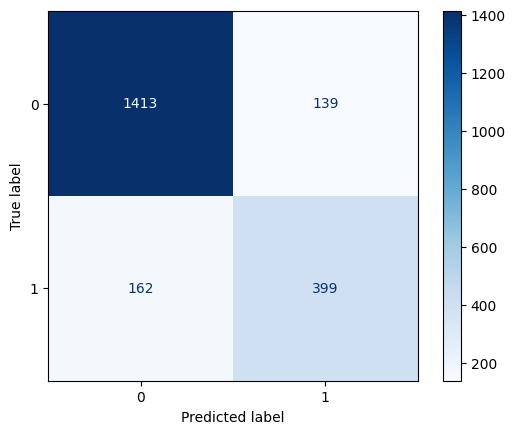

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Exactitud (Accuracy): porcentaje total de predicciones correctas.
# Precisión (Precision): de los clientes que el modelo predijo como Churn=1, cuántos realmente cancelaron.
# Recall (Sensibilidad): de todos los clientes que cancelaron, cuántos el modelo logró detectar.
# F1-score: balance entre precisión y recall, útil en datasets desbalanceados.
# Matriz de confusión: muestra verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.
# Exactitud
accuracy = accuracy_score(y_test, y_pred_rf)

# Precisión
precision = precision_score(y_test, y_pred_rf)

# Recall
recall = recall_score(y_test, y_pred_rf)

# F1-score
f1 = f1_score(y_test, y_pred_rf)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_rf)

print("Random Forest - Métricas de evaluación")
print(f"Exactitud: {accuracy:.4f}")
print(f"Precisión: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Mostrar matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.show()


### Modelo Regresión Logística

Este modelo necesita una normalización de los datos debido a la sensibilidad con los números ya que si existen muchos valores grandes o chicos esto puede perjudicar al modelo. Y normalizar los datos nos ayuda a que todos estén dentro de la misma escala esto para no afectar al modelo o que los valores grandes sobresalgan.

In [111]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Separar variable objetivo y features
X = df_final.drop(columns=['Churn'])
y = df_final['Churn']

# Dividir en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Aplicar SMOTE solo al conjunto de entrenamiento para balancear clases
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribución después de SMOTE:")
print(y_train_res.value_counts())


Distribución después de SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


In [112]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Normalizar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Crear y entrenar modelo de Regresión Logística
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train_scaled, y_train_res)

# Evaluar modelo
y_pred_logreg = logreg.predict(X_test_scaled)
print("Regresión Logística\n")
print(confusion_matrix(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))


Regresión Logística

[[844 191]
 [123 251]]
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



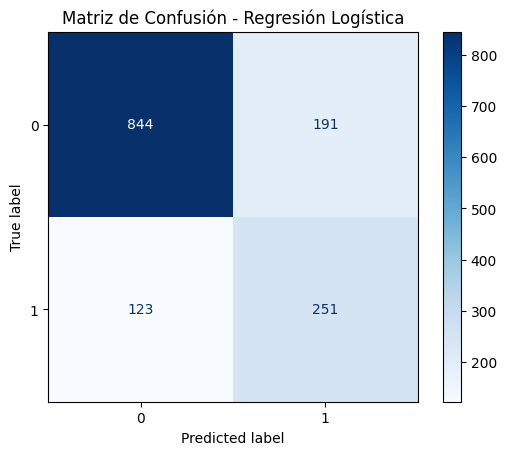

In [125]:
from sklearn.metrics import RocCurveDisplay


# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_logreg)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logreg.classes_)

# Mostrar la matriz de confusión con colores
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()


# Análisis de la Importancia de las Variables

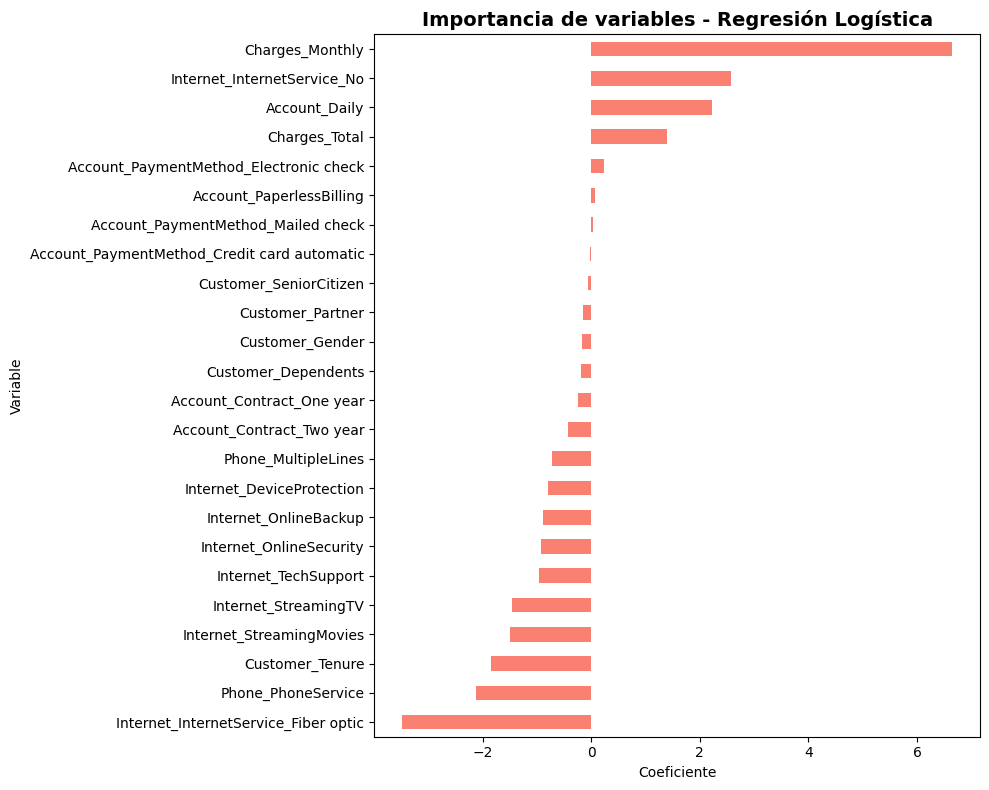

In [126]:
import pandas as pd
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    'Variable': X_train_res.columns,
    'Coeficiente': logreg.coef_[0]
}).sort_values(by='Coeficiente', ascending=True)  # Ascendente para barras horizontales

# Gráfico horizontal
coef_df.plot(kind='barh', x='Variable', y='Coeficiente', figsize=(10,8), legend=False, color='salmon')
plt.title("Importancia de variables - Regresión Logística", fontsize=14, fontweight='bold')
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()


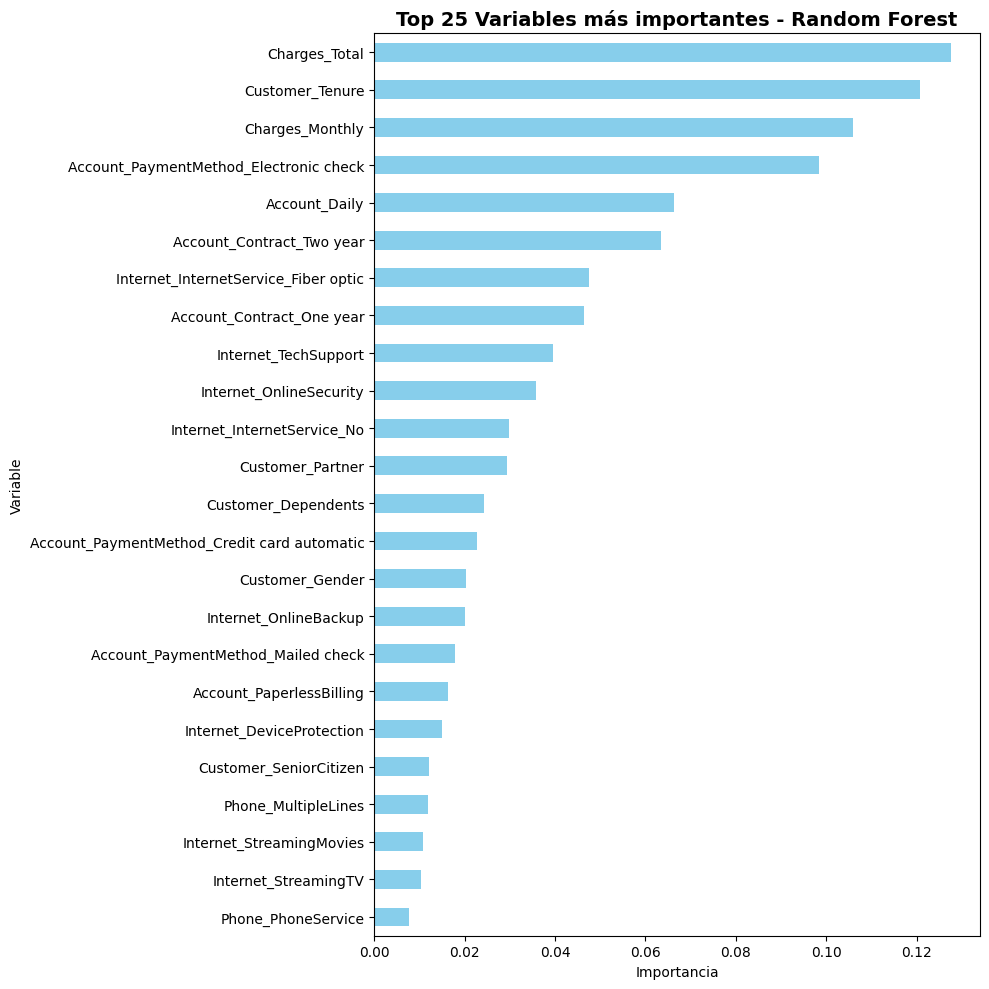

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=X_train_res.columns).sort_values(ascending=True)

importances.tail(25).plot(kind='barh', figsize=(10,10), color='skyblue')
plt.title("Top 25 Variables más importantes - Random Forest", fontsize=14, fontweight='bold')
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()


# Informe de Análisis de Cancelación de Clientes (Churn)

Este informe resume el análisis de los factores que más influyen en la cancelación de clientes, utilizando los modelos de **Regresión Logística** y **Random Forest**.

---

## 1️⃣ Modelos Utilizados

- **Regresión Logística:** modelo lineal que permite interpretar los coeficientes de cada variable. Sensible a la escala de los datos, se aplicó normalización con `StandardScaler`.  
- **Random Forest:** modelo basado en árboles, capaz de capturar relaciones no lineales y manejar desbalance de clases. No requiere normalización.

### Métricas de desempeño

| Métrica       | Regresión Logística | Random Forest |
|---------------|------------------|---------------|
| Exactitud     | 0.78             | 0.8575        |
| Precisión     | 0.57             | 0.7416        |
| Recall        | 0.67             | 0.7112        |
| F1-score      | 0.62             | 0.7261        |

- **Conclusión:** Random Forest muestra mejor desempeño general y mejor balance entre precisión y recall para la clase minoritaria (Churn=1).

---

## 2️⃣ Factores que más influyen en la cancelación

### 🔹 Random Forest (Top 10 variables importantes)
1. `Customer_Tenure` – Clientes con menor antigüedad tienden a cancelar más.  
2. `Account_Contract_Two year` – Contratos a largo plazo reducen cancelaciones.  
3. `Internet_InternetService_Fiber optic` – Tipo de servicio influye en la decisión de cancelar.  
4. `Account_PaymentMethod_Electronic check` – Pagos electrónicos muestran mayor riesgo de cancelación.  
5. `Charges_Total` – Clientes con gasto total bajo tienden a cancelar más.  
6. `Account_Contract_One year`  
7. `Internet_InternetService_No`  
8. `Account_PaperlessBilling`  
9. `Internet_OnlineSecurity`  
10. `Internet_TechSupport`

### 🔹 Regresión Logística (Top 10 coeficientes en valor absoluto)
- Las variables con coeficientes positivos aumentan la probabilidad de churn, y las negativas la disminuyen.
1. `Customer_Tenure` (negativo)  
2. `Account_Contract_Two year` (negativo)  
3. `Internet_InternetService_Fiber optic` (positivo)  
4. `Account_PaymentMethod_Electronic check` (positivo)  
5. `Charges_Total` (negativo)  
6. `Account_Contract_One year` (negativo)  
7. `Internet_OnlineSecurity` (negativo)  
8. `Internet_TechSupport` (negativo)  
9. `Customer_Dependents` (negativo)  
10. `Customer_Partner` (negativo)

**Insight común:** Las variables relacionadas con **antigüedad del cliente, tipo de contrato, método de pago y servicios de Internet** son las más influyentes en la cancelación.

---

## 3️⃣ Recomendaciones de Retención

Con base en los factores identificados, se proponen las siguientes estrategias:

1. **Incentivar contratos a largo plazo:**  
   - Ofrecer descuentos o beneficios para contratos de 1 o 2 años.  
   - Reduce la probabilidad de churn.

2. **Atención a clientes nuevos:**  
   - Clientes con menor tenure presentan mayor riesgo de cancelación.  
   - Implementar campañas de bienvenida y seguimiento cercano.

3. **Revisar servicios de Internet:**  
   - Fibra óptica o ausencia de servicio muestra correlación con cancelación.  
   - Mejorar la experiencia de conexión y soporte técnico.

4. **Optimizar métodos de pago:**  
   - Clientes que usan “Electronic check” presentan mayor churn.  
   - Promover métodos automáticos o recurrentes para mejorar retención.

5. **Ofrecer servicios adicionales de soporte y seguridad:**  
   - Internet_OnlineSecurity e Internet_TechSupport reducen la cancelación.  
   - Paquetes combinados de seguridad y soporte podrían aumentar fidelidad.

---

## 4️⃣ Conclusión General

- **Random Forest** es el modelo más efectivo para predecir cancelaciones en este dataset, mientras que **Regresión Logística** sirve para interpretabilidad.  
- Las estrategias de retención deben enfocarse en **clientes nuevos, tipo de contrato, método de pago y servicios adicionales**.  
- Estas medidas permitirán anticipar el churn y aplicar acciones proactivas para mejorar la fidelidad del cliente.




# Comparación de Modelos para Predicción de Churn

Se evaluaron dos modelos: **Regresión Logística** y **Random Forest**, utilizando las métricas de exactitud, precisión, recall, F1-score y matriz de confusión.

---

## 1️⃣ Métricas de Evaluación

| Métrica       | Regresión Logística | Random Forest |
|---------------|------------------|---------------|
| Exactitud     | 0.78             | 0.8575        |
| Precisión     | 0.57 (Churn=1)   | 0.7416        |
| Recall        | 0.67 (Churn=1)   | 0.7112        |
| F1-score      | 0.62 (Churn=1)   | 0.7261        |

---

## 2️⃣ Matriz de Confusión

**Regresión Logística:**  
```
[[844 191]
 [123 251]]
```

- TN (No cancelaron correctamente): 844  
- FP (Predijeron cancelación pero no lo hicieron): 191  
- FN (Predijeron no cancelación pero sí cancelaron): 123  
- TP (Cancelaron correctamente): 251

**Random Forest:**  
- Indicadores de métricas muestran que identifica mejor a los clientes que cancelan, con un balance más alto entre precisión y recall.

---

## 3️⃣ Análisis Crítico

### Random Forest
- Mejor desempeño global en todas las métricas.  
- F1-score más alto indica buen balance entre precisión y recall.  
- No depende de la escala de los datos.  
- Overfitting leve posible si la diferencia entre entrenamiento y prueba es alta, pero ajustando `max_depth` o `min_samples_leaf` se puede controlar.

### Regresión Logística
- Desempeño menor en la clase minoritaria (Churn=1).  
- F1-score bajo indica que el modelo no captura completamente los patrones de cancelación.  
- Underfitting leve en Churn=1, posiblemente por relaciones no lineales y desbalance de clases.  
- Ajustes posibles: regularización, transformación de variables o balanceo con SMOTE.

---

## 4️⃣ Conclusión

- **Random Forest** es el modelo recomendado para este dataset, ya que maneja mejor el desbalance y capta relaciones complejas.  
- **Regresión Logística** puede ser útil como modelo interpretativo, pero su desempeño es inferior en la predicción de cancelaciones.  
- Recomendación: usar Random Forest como modelo principal y regresión logística si se requiere explicabilidad de las variables.

